In [1]:
import json
import glob
import pandas as pd
import re
from collections import defaultdict

In [2]:


results = defaultdict(dict)

pattern = re.compile(r"^(?P<base>.*)_num_reads_(?P<num>\d+)$")

for annealing in ['QA', 'SA']:
    for path in glob.glob(f"results/Advantage2_system1.8/{annealing}/*/*/*/*/*"):
        # Build your name the same way as before (but based on path)
        name = "_".join(path[len("results/"):-len(".json")
                            ].split("/")).replace(f"{annealing}_", "")

        m = pattern.match(name)
        if not m:
            # If you want to be strict, raise; otherwise skip
            # raise ValueError(f"Expected name to end with _num_reads_<N>, got: {name}")
            continue

        base_name = m.group("base")
        num_reads = int(m.group("num"))

        with open(path) as f:
            data = json.load(f)

        results[base_name][annealing] = {
            'value': data["value"], 'time': data['time']}

# optional: convert back to a normal dict
results = dict(results)

In [3]:
with open('results_qasa.json') as f:
    results_qsa= json.load(f)

In [10]:
comparisons = {}
solved = []
for file in glob.glob('sid_res/*'):
    instance_name = file[len('sid_res/'):-len('.json.output.json')]
    solved.append(instance_name)
    with open(file) as f:
        data = json.load(f)
    comp_value = data['qubo']['computed_val'] / 28
    expected_value_qa = results_qsa[instance_name]["QA"]
    expected_value_qa = results_qsa[instance_name]["SA"]

solved[0]

'Advantage2_system1.8_send_8_m10_case0_beta0.0_J_log'

In [ ]:
unsolved_jlog = []
unsolved_jqac = []

for instance in results_qsa:
    if instance not in solved:
        if 'log' in instance:
            unsolved_jlog.append(instance)
        else:
            
unsolved_jlog

['Advantage2_system1.8_send_8_m9_case3_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case4_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case1_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case0_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case2_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case7_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case6_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case5_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case9_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m9_case8_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m12_case3_beta0.0_J_log',
 'Advantage2_system1.8_send_8_m12_case3_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m12_case4_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m12_case1_beta0.0_J_log',
 'Advantage2_system1.8_send_8_m12_case1_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m12_case0_beta0.0_J_qac',
 'Advantage2_system1.8_send_8_m12_case2_beta0.0_J_log',
 'Advantage2_system1.8_send_8_m12_case2_beta0.0_J_qac',
 '

In [5]:
import os
import re
import glob
import json
import pandas as pd

# find m/case/beta anywhere inside the name
name_re = re.compile(
    r"m(?P<m>\d+)_case(?P<case_num>\d+)_beta(?P<beta>-?\d+(?:\.\d+)?)"
    r"(?:_(?P<suffix>.*))?$"
)

rows = []

for file in glob.glob("sid_res/*"):
    base = os.path.basename(file)

    # strip the exact suffix safely
    suffix = ".json.output.json"
    if not base.endswith(suffix):
        # if files differ, don’t silently lie
        raise ValueError(f"Unexpected filename suffix: {base}")
    instance_name = base[:-len(suffix)]

    with open(file) as f:
        data = json.load(f)

    comp_value = data["qubo"]["computed_val"] / 28

    qa = results_qsa[instance_name]["QA"]
    sa = results_qsa[instance_name]["SA"]

    mobj = name_re.search(instance_name)
    if not mobj:
        # show the string that failed so you can see what it actually looks like
        raise ValueError(
            f"Could not parse m/case/beta from instance_name: {instance_name}")

    m_val = int(mobj.group("m"))
    case_val = int(mobj.group("case_num"))
    beta_val = float(mobj.group("beta"))

    # suffix is whatever remains after beta..._
    suffix_val = mobj.group("suffix") or ""
    qa_abs_diff = qa["value"] - comp_value
    sa_abs_diff = sa["value"] - comp_value

    rows.append({
        "instance_name": instance_name[len('Advantage2_system1.8_send_8_m3_'):],
        "m": m_val,
        "case_num": case_val,
        "beta": beta_val,
        "log_qac": suffix_val,
        "biqbin": comp_value,
        "QA_value": qa["value"],
        "SA_value": sa["value"],
        "biqbin_time": data["meta_data"]["time"],
        "bab_nodes": data["meta_data"]["eval_bab_nodes"],
        "qa_time": qa["time"],
        "sa_time": sa["time"],
        "abs_diff_qa_biq": qa_abs_diff,
        "abs_diff_sa_biq": sa_abs_diff,
        "rel_diff_qa_biq": qa_abs_diff * 100/-comp_value,
        "rel_diff_sa_biq": sa_abs_diff * 100/-comp_value
    })

df = pd.DataFrame(rows)
df.sort_values('abs_diff_qa_biq')

,instance_name,m,case_num,beta,log_qac,biqbin,QA_value,SA_value,biqbin_time,bab_nodes,qa_time,sa_time,abs_diff_qa_biq,abs_diff_sa_biq,rel_diff_qa_biq,rel_diff_sa_biq
109,case4_beta0.0_J_qac,5,4,0.0,J_qac,-586.500000,-586.500000,-584.500000,2941.879937,193,0.012341,0.650776,-3.524292e-12,2.000000e+00,-6.009023e-13,3.410060e-01
150,case3_beta0.0_J_log,8,3,0.0,J_log,-545.142857,-545.142857,-544.071429,843.221066,41,0.012369,5.479420,-3.183231e-12,1.071429e+00,-5.839261e-13,1.965409e-01
156,case9_beta0.0_J_log,8,9,0.0,J_log,-558.071429,-558.071429,-557.500000,1510.770040,77,0.010918,5.748336,-2.501110e-12,5.714286e-01,-4.481703e-13,1.023934e-01
111,case5_beta0.0_J_qac,5,5,0.0,J_qac,-572.464286,-572.464286,-569.250000,5118.298733,343,0.012439,0.616222,-2.273737e-12,3.214286e+00,-3.971840e-13,5.614823e-01
144,case7_beta0.0_J_log,7,7,0.0,J_log,-426.321429,-426.321429,-426.321429,178.586479,123,0.009492,4.149546,-2.160050e-12,-2.160050e-12,-5.066717e-13,-5.066717e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,_case9_beta0.0_J_log,12,9,0.0,J_log,-1226.321429,-1223.107143,-1219.821429,53087.757038,16065,0.030787,12.210161,3.214286e+00,6.500000e+00,2.621079e-01,5.300405e-01
131,case6_beta0.0_J_qac,6,6,0.0,J_qac,-875.642857,-872.357143,-868.714286,30093.050115,2255,0.018183,0.909063,3.285714e+00,6.928571e+00,3.752345e-01,7.912554e-01
161,case4_beta0.0_J_log,9,4,0.0,J_log,-687.892857,-684.535714,-685.892857,4124.861116,43,0.014791,7.099607,3.357143e+00,2.000000e+00,4.880328e-01,2.907430e-01
3,_case4_beta0.0_J_log,10,4,0.0,J_log,-866.250000,-862.892857,-861.392857,6361.126541,1799,0.016260,8.751345,3.357143e+00,4.857143e+00,3.875490e-01,5.607091e-01


In [6]:
df.to_excel('result_comparison.xlsx')
df.to_csv('result_comparison.csv')

In [7]:
import matplotlib.pyplot as plt

# J_log table

In [6]:
jlogs = df[df['log_qac'] == 'J_log']
jlogs.count()

instance_name      110
m                  110
case_num           110
beta               110
log_qac            110
biqbin             110
QA_value           110
SA_value           110
biqbin_time        110
bab_nodes          110
qa_time            110
sa_time            110
abs_diff_qa_biq    110
abs_diff_sa_biq    110
rel_diff_qa_biq    110
rel_diff_sa_biq    110
dtype: int64

In [7]:
jlogs

,instance_name,m,case_num,beta,log_qac,biqbin,QA_value,SA_value,biqbin_time,bab_nodes,qa_time,sa_time,abs_diff_qa_biq,abs_diff_sa_biq,rel_diff_qa_biq,rel_diff_sa_biq
0,_case0_beta0.0_J_log,10,0,0.0,J_log,-875.750000,-874.321429,-873.678571,6817.735114,293,0.017361,8.742793,1.428571,2.071429,0.163125,0.236532
1,_case2_beta0.0_J_log,10,2,0.0,J_log,-860.392857,-860.321429,-857.178571,9848.663735,311,0.017073,10.244693,0.071429,3.214286,0.008302,0.373583
2,_case3_beta0.0_J_log,10,3,0.0,J_log,-860.821429,-860.607143,-857.821429,6185.129947,1207,0.020387,8.536255,0.214286,3.000000,0.024893,0.348504
3,_case4_beta0.0_J_log,10,4,0.0,J_log,-866.250000,-862.892857,-861.392857,6361.126541,1799,0.016260,8.751345,3.357143,4.857143,0.387549,0.560709
4,_case5_beta0.0_J_log,10,5,0.0,J_log,-856.892857,-855.464286,-853.107143,8902.249389,1389,0.017288,8.533207,1.428571,3.785714,0.166715,0.441796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,case5_beta0.0_J_log,9,5,0.0,J_log,-687.357143,-685.714286,-685.928571,7246.515591,723,0.014822,7.150879,1.642857,1.428571,0.239011,0.207835
163,case6_beta0.0_J_log,9,6,0.0,J_log,-702.821429,-701.392857,-701.107143,4380.539996,221,0.015971,7.106321,1.428571,1.714286,0.203262,0.243915
164,case7_beta0.0_J_log,9,7,0.0,J_log,-694.821429,-694.607143,-692.392857,2306.638981,73,0.017441,7.235172,0.214286,2.428571,0.030840,0.349525
165,case8_beta0.0_J_log,9,8,0.0,J_log,-703.214286,-702.000000,-700.642857,2117.401350,743,0.016552,6.965289,1.214286,2.571429,0.172676,0.365668


# Relative differences between Biqbin results vs QA or SA

<Figure size 640x480 with 0 Axes>

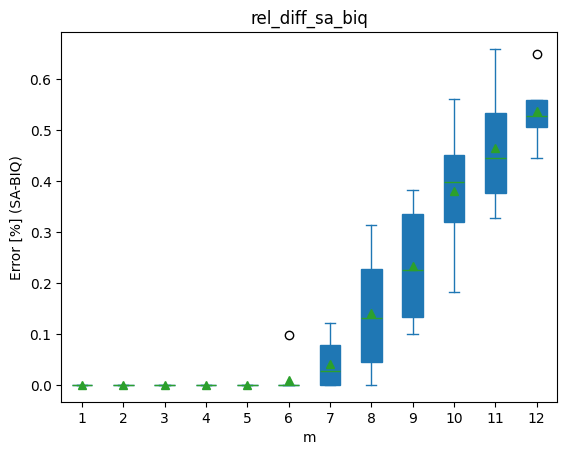

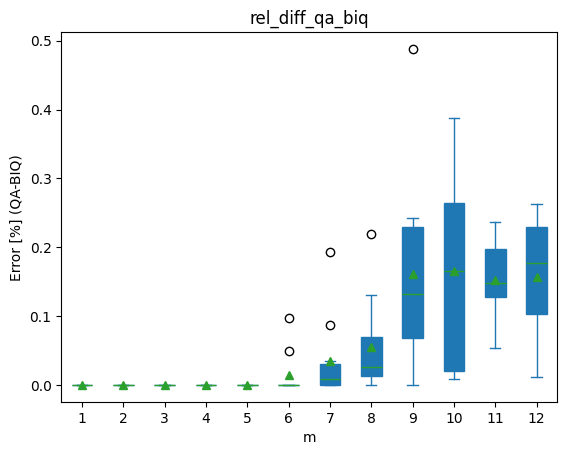

In [19]:
myFig = plt.figure()
# ax = jlogs.reset_index().plot.box(column='abs_diff_sa_biq', by=['m'], xlabel='m', ylabel='Error Absolute (SA-BIQ)', logy=False, showmeans=True, patch_artist=True)
ax = jlogs.reset_index().plot.box(column='rel_diff_sa_biq', by=['m'], xlabel='m', ylabel='Error [%] (SA-BIQ)', logy=False, showmeans=True, patch_artist=True)
# ax = jlogs.reset_index().plot.box(column='abs_diff_qa_biq', by=['m'], xlabel='m', ylabel='Error Absolute (QA-BIQ)', logy=False, showmeans=True, patch_artist=True)
ax = jlogs.reset_index().plot.box(column='rel_diff_qa_biq', by=['m'], xlabel='m', ylabel='Error [%] (QA-BIQ)', logy=False, showmeans=True, patch_artist=True)


# Compute time and branch nodes explored
## J_log instances

<Figure size 640x480 with 0 Axes>

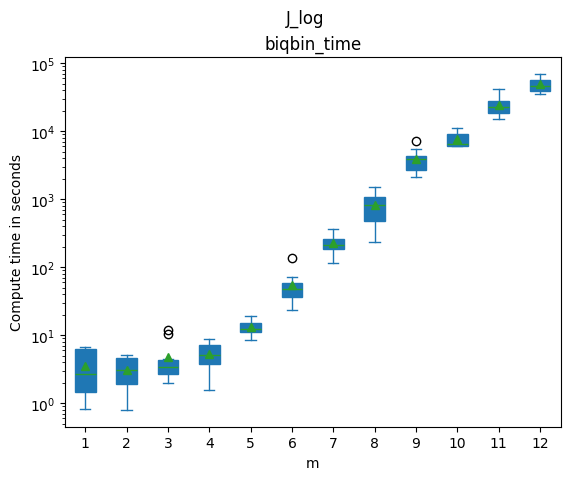

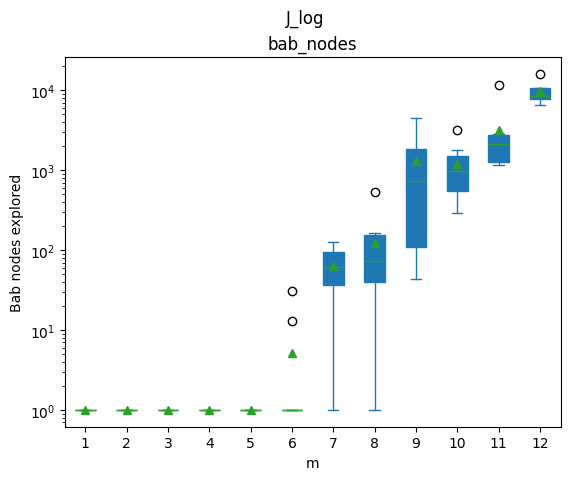

In [16]:
myFig = plt.figure()
ax = jlogs.reset_index().plot.box(column='biqbin_time', title="J_log",by=['m'], xlabel='m', ylabel='Compute time in seconds', logy=True, showmeans=True, patch_artist=True)
ax = jlogs.reset_index().plot.box(column='bab_nodes', title="J_log",by=['m'], xlabel='m', ylabel='Bab nodes explored', logy=True, showmeans=True, patch_artist=True)


## J_qac instances

<Figure size 640x480 with 0 Axes>

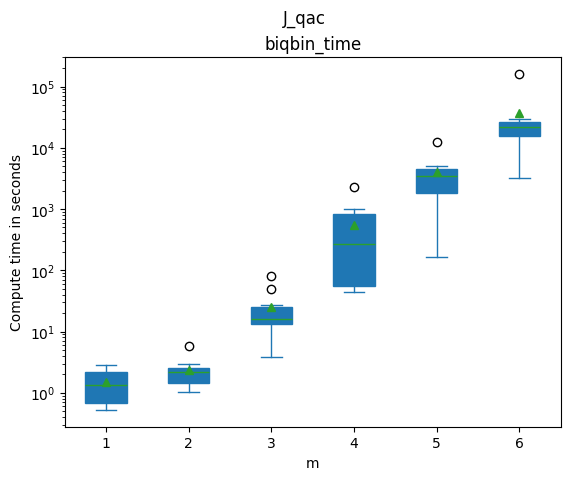

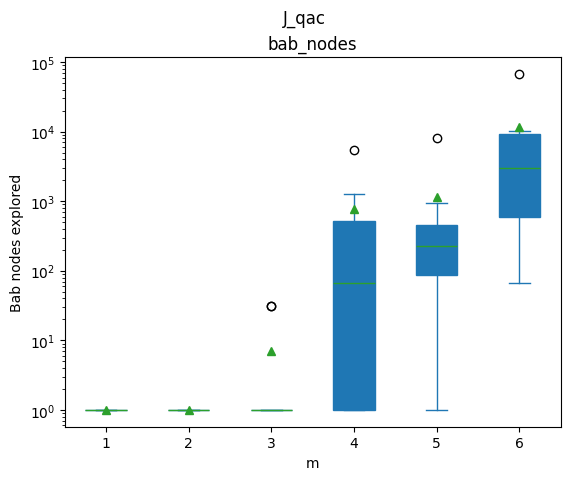

In [17]:
myFig = plt.figure()
ax = df[df['log_qac'] == 'J_qac'].reset_index().plot.box(column='biqbin_time', title="J_qac", by=['m'], xlabel='m', ylabel='Compute time in seconds', logy=True, showmeans=True, patch_artist=True)
ax = df[df['log_qac'] == 'J_qac'].reset_index().plot.box(column='bab_nodes',title="J_qac", by=['m'], xlabel='m', ylabel='Bab nodes explored', logy=True, showmeans=True, patch_artist=True)

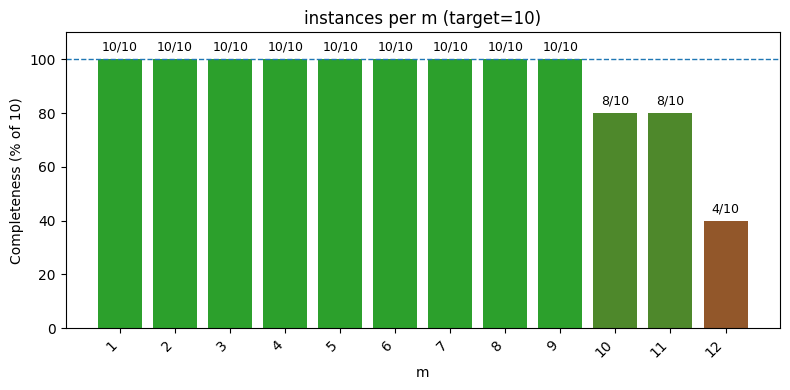

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

TARGET = 10


# counts per m
counts = jlogs.groupby("m").size().sort_index()

# percent completeness (0..100). If you can have >10, cap at 100 for color/height.
pct = (counts / TARGET * 100).clip(upper=100)

# red->green colormap for incomplete groups
cmap = LinearSegmentedColormap.from_list("red_green", ["#d62728", "#2ca02c"])

colors = []
for m, c in counts.items():
    if c == TARGET:
        colors.append("#2ca02c")  # pure green
    else:
        # map percent (0..100) to a gradient color
        colors.append(to_hex(cmap(pct.loc[m] / 100.0)))

# plot
plt.figure(figsize=(max(8, len(counts) * 0.6), 4))
bars = plt.bar(counts.index.astype(str), pct.values, color=colors)

plt.axhline(100, linestyle="--", linewidth=1)
plt.ylabel(f"Completeness (% of {TARGET})")
plt.xlabel("m")
plt.title("instances per m (target=10)")
plt.xticks(rotation=45, ha="right")

# annotate each bar with "count/10"
for x, c, p in zip(range(len(counts)), counts.values, pct.values):
    plt.text(x, min(p + 2, 103), f"{c}/{TARGET}", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()


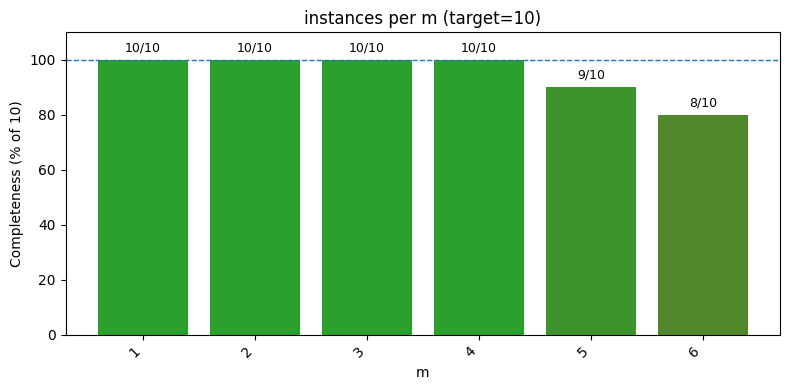

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

TARGET = 10


# counts per m
counts = df[df['log_qac'] == 'J_qac'].groupby("m").size().sort_index()

# percent completeness (0..100). If you can have >10, cap at 100 for color/height.
pct = (counts / TARGET * 100).clip(upper=100)

# red->green colormap for incomplete groups
cmap = LinearSegmentedColormap.from_list("red_green", ["#d62728", "#2ca02c"])

colors = []
for m, c in counts.items():
    if c == TARGET:
        colors.append("#2ca02c")  # pure green
    else:
        # map percent (0..100) to a gradient color
        colors.append(to_hex(cmap(pct.loc[m] / 100.0)))

# plot
plt.figure(figsize=(max(8, len(counts) * 0.6), 4))
bars = plt.bar(counts.index.astype(str), pct.values, color=colors)

plt.axhline(100, linestyle="--", linewidth=1)
plt.ylabel(f"Completeness (% of {TARGET})")
plt.xlabel("m")
plt.title("instances per m (target=10)")
plt.xticks(rotation=45, ha="right")

# annotate each bar with "count/10"
for x, c, p in zip(range(len(counts)), counts.values, pct.values):
    plt.text(x, min(p + 2, 103), f"{c}/{TARGET}", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()
